# Aufgabe 5

## Prototyping mit Zero-Shot-Detektoren
Szenario: Eine Stadtverwaltung möchte an einer Kreuzung den Verkehr automatisch
erfassen, um das Aufkommen von Fuß-, Rad- und KFZ-Verkehr zu quantifizieren. Sie
werden als ML Engineer mit einem schnellen Proof of Concept beauftragt: ein
Prototyp, der Verkehrsteilnehmer in Bildern erkennt – ohne Zeit und Budget für das
Sammeln und Annotieren eigener Trainingsdaten. Prüfen Sie, wie weit man ohne
jegliches Finetuning (zero-shot) mit heutigen Foundation-Modellen kommt, und
stellen Sie erste Ergebnisse vor.

Datensatz: Nutzen Sie COCO. COCO enthält die relevanten Verkehrsklassen mit
Bounding Boxes (sowie Instanzmasken). Relevante Klassen für dieses Szenario sind
z. B.: person, bicycle, car, motorcycle, bus, truck, traffic light

Der untenstehende Lade-Code filtert COCO automatisch auf die Verkehrsklassen und
liefert für jedes Bild die Ground Truth (Boxen und Klassennamen) in einem
einheitlichen Format.
Wählen Sie daraus eine sinnvolle Teilmenge (ca. 30–50 Bilder) für Ihren PoC und
begründen Sie kurz Ihre Auswahl (z. B. Szenen mit mehreren Verkehrsteilnehmern,
unterschiedliche Lichtverhältnisse, Verdeckungen).

In [7]:
from pycocotools.coco import COCO
import numpy as np, requests
from PIL import Image; from io import BytesIO

TRAFFIC = ['person','bicycle','car','motorcycle','bus','truck','traffic light']
coco = COCO('annotations/instances_val2017.json')
cat_ids = coco.getCatIds(catNms=TRAFFIC)
name_of = {c['id']: c['name'] for c in coco.loadCats(coco.getCatIds())}

def select_images(min_classes=2, max_images=50):
    """Bilder mit mindestens `min_classes` verschiedenen Verkehrsklassen."""
    chosen = []
    for img_id in coco.getImgIds():
        anns = coco.loadAnns(coco.getAnnIds(imgIds=img_id, catIds=cat_ids, iscrowd=False))
        if len({a['category_id'] for a in anns}) >= min_classes:
            chosen.append(img_id)
        if len(chosen) >= max_images:
            break
    return chosen

def load_image(img_id):
    info = coco.loadImgs(img_id)[0]
    img = Image.open(BytesIO(requests.get(info['coco_url']).content)).convert('RGB')
    return img, info

def load_gt(img_id):
    """Ground Truth im einheitlichen Format: boxes (XYXY), labels (Namen)."""
    anns = coco.loadAnns(coco.getAnnIds(imgIds=img_id, catIds=cat_ids, iscrowd=False))
    boxes, labels = [], []
    for a in anns:
        x, y, w, h = a['bbox']
        boxes.append([x, y, x+w, y+h])  # COCO XYWH -> XYXY
        labels.append(name_of[a['category_id']])  # Klassennamen statt IDs
    return {'boxes': np.array(boxes, float), 'labels': labels}

ids = select_images(min_classes=2)
print(f'{len(ids)} Bilder ausgewählt. Beispiel-GT:', load_gt(ids[0])['labels'])
# Bild zur Inferenz laden: img, info = load_image(ids[0])
# img an Ihr Detektionsmodell übergeben (Teilaufgabe c).

loading annotations into memory...
Done (t=0.82s)
creating index...
index created!
50 Bilder ausgewählt. Beispiel-GT: ['person', 'person', 'person', 'traffic light']


### Teilaufgabe A
Recherchieren Sie aktuelle Objektdetektoren. Ordnen Sie mindestens vier Modelle
in die Kategorien Closed-Set und Open-Vocabulary ein. Begründen Sie, warum sich
für eine Evaluierung ohne jegliches Finetuning nur bestimmte Modelle eignen.
Wählen Sie auf dieser Basis ein geeignetes Modell für Ihren Prototyp und
begründen Sie die Wahl.



* **Closed-Set:** YOLOv8, Faster R-CNN -> Modelle sind auf einen festen Satz von Klassen trainiert
* **Open-Vocabulary:** Grounding DINO, YOLO-World. Modelle können Objekte auf Text-Prompts erkennen, ohne explizit für diese Klassen trainiert zu sein

Open-Vocabulary, für zero-shot Evaluierung (ohne Finetuning) erforderlich, da Inferenz flexibel auf neue Klassennamen reagieren können, während Closed-Set-Modelle auf ihre festen Ausgabeschichten angewiesen sind.

Wahl: Grounding DINO:
- state-of-the-art
- robust in zero-shot
- gut mit COCO-ähnlichen Szenarien

### Teilaufgabe B

Die modernen Open-Vocabulary-Modelle beruhen auf der Attention-/TransformerArchitektur, die wir in der Vorlesung nicht vertieft haben. Erklären Sie in 4-6
Sätzen die Grundidee von Attention auf hoher Ebene und warum gerade sie OpenVocabulary-Detektion ermöglicht, während ein klassisches CNN mit Softmax-Kopf
auf einen festen Satz von Ausgabeklassen beschränkt bleibt.

Attention hilft einem Modell, sich genau auf die wichtigsten Dinge in Daten zu konzentrieren. Dadurch kann das Modell Bilder direkt mit jedem beliebigen Wort verknüpfen, auch wenn es das Wort vorher noch nie gesehen hat. Klassiche Modelle kennen im Gegensatz dazu nur eine feste, auswendig gelernte Liste von Begriffen. Um etwas Neues zu erkennen, müssten diese alten Modelle erst aufwendig neu trainiert werden.


### Teilaufgabe C
Lassen Sie Ihr gewähltes Modell auf den Bildern laufen, um Bounding Boxen
vorherzusagen. Da die drei empfohlenen Modelle ihre Ergebnisse unterschiedlich
zurückgeben, schreiben Sie eine kleine Funktion, die die Ausgabe Ihres Modells in
ein einheitliches Format überführt – eine Liste von Boxen (XYXY), zugehörige
Scores und Klassennamen – passend zum Ground-Truth-Format aus load_gt(...).
Konsultieren Sie dazu die Dokumentation Ihres Modells.
Experimentieren Sie außerdem mit den Text-Prompts (z. B. „person“ vs. „a
pedestrian crossing the street“) und unterschiedlichen Konfidenzen. Visualisieren
Sie einige Beispielausgaben und dokumentieren Sie, wie stark Prompt und
Schwellwerte das Ergebnis verändern.


Lade Modell...


Loading weights: 100%|██████████| 978/978 [00:00<00:00, 4517.96it/s]


Modell erfolgreich geladen!


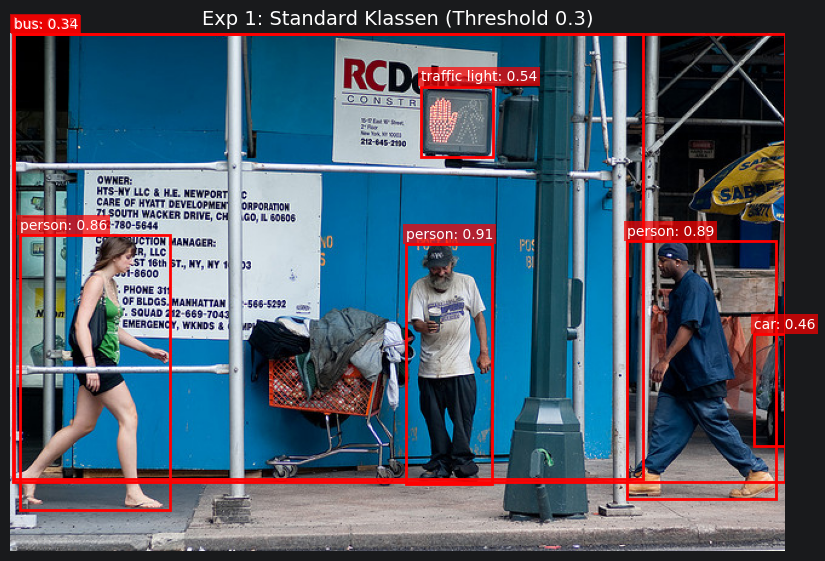

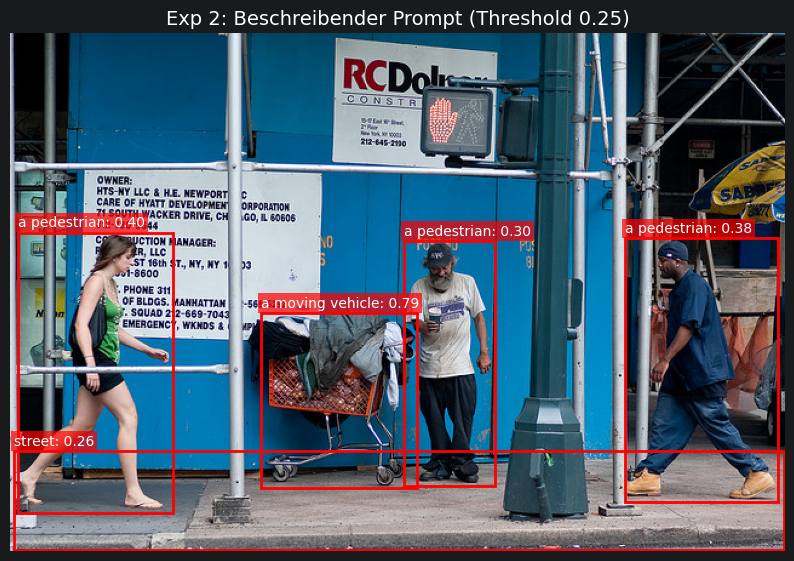

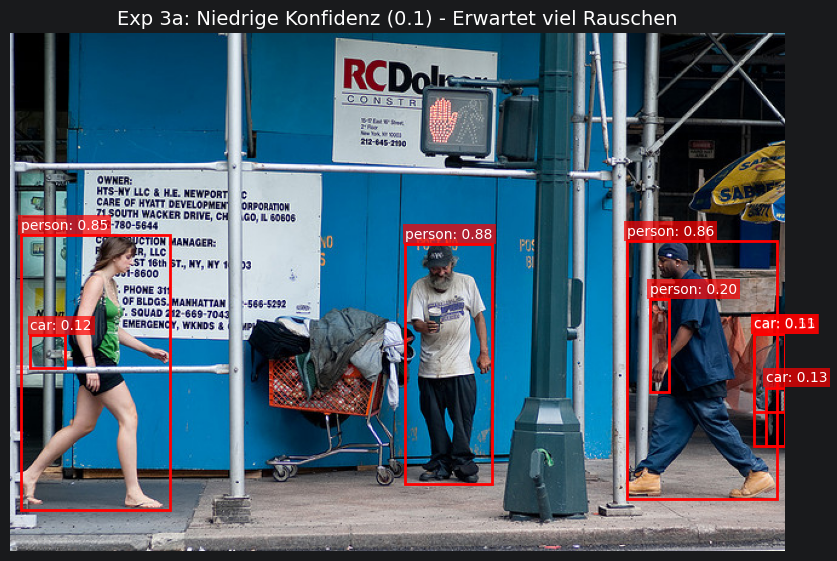

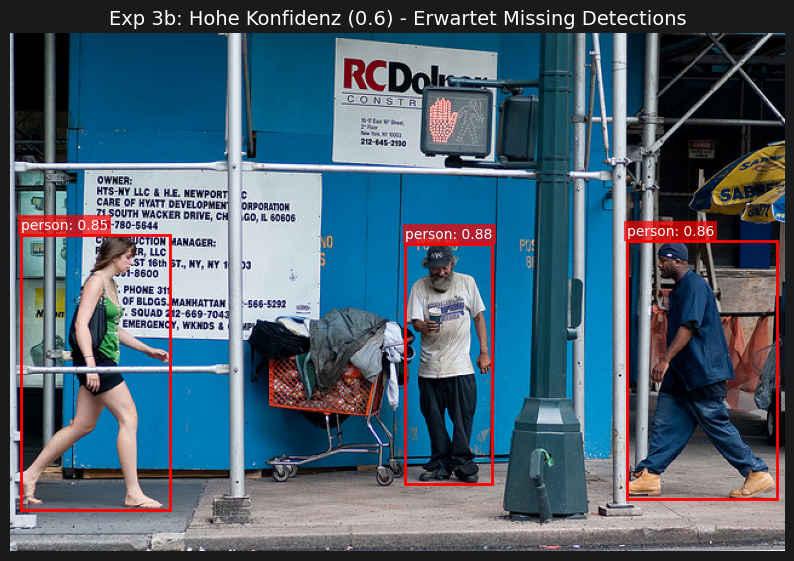

In [8]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

# --- 1. Grounding DINO Modell und Processor laden ---
# - Prüft, ob eine schnelle Grafikkarte (GPU / "cuda") verfügbar ist, sonst wird der Standard-Prozessor (CPU) genutzt
device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "IDEA-Research/grounding-dino-tiny"

print("Lade Modell...")
# - Lädt den Processor (bereitet Bilder und Texte vor) und das eigentliche KI-Modell herunter
processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(device)
print("Modell erfolgreich geladen!")

# --- 2. Einheitliche Formatierungs- und Inferenzfunktion ---
def predict_and_format(image, prompt, box_threshold=0.3, text_threshold=0.3):
    """
    - Führt die Objekterkennung mit dem Grounding DINO Modell durch.
    - Sucht in einem Bild nach den Dingen, die im Text (Prompt) beschrieben werden.
    - Gibt die Ergebnisse einheitlich formatiert zurück (Rahmen, Sicherheitsscore, Klassenname).
    """
    # - Wandelt Bild und Text in ein Zahlenformat (Tensoren) um, das das Modell verarbeiten kann
    inputs = processor(images=image, text=prompt, return_tensors="pt").to(device)

    # - Lässt das Modell Vorhersagen treffen
    # - "torch.no_grad()" spart Speicher, da wir das Modell nur anwenden und nicht trainieren
    with torch.no_grad():
        outputs = model(**inputs)

    # - Ermittelt die Größe des Originalbildes (Höhe, Breite) für die Rückrechnung
    target_sizes = torch.tensor([image.size[::-1]])

    # - Filtert zu unsichere Vorhersagen anhand der Schwellenwerte (Thresholds) heraus
    # - Rechnet die internen Modell-Koordinaten auf die echte Bildgröße um
    results = processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        threshold=box_threshold,
        text_threshold=text_threshold,
        target_sizes=target_sizes
    )[0]

    # - Packt die aufbereiteten Daten in ein übersichtliches Dictionary
    # - ".cpu().numpy()" verschiebt die Daten von der Grafikkarte zurück in den normalen Arbeitsspeicher
    formatted_output = {
        'boxes': results['boxes'].cpu().numpy(),
        'scores': results['scores'].cpu().numpy(),
        'labels': results['labels']
    }

    return formatted_output

# --- 3. Hilfsfunktion zur Visualisierung ---
def plot_predictions(image, predictions, title=""):
    """
    - Zeichnet die vom Modell gefundenen Objekte als Rechtecke auf das Originalbild.
    - Beschriftet jedes Rechteck mit dem erkannten Namen und der Genauigkeit.
    """
    # - Erstellt eine leere Zeichenfläche und legt das Originalbild als Hintergrund fest
    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(image)
    ax.axis('off') # Schaltet die störenden Zahlenränder (Achsen) aus
    ax.set_title(title, fontsize=14)

    # - Geht durch jede einzelne Vorhersage (Rahmen, Score, Label)
    for box, score, label in zip(predictions['boxes'], predictions['scores'], predictions['labels']):
        # - Zerlegt die Box in linke, obere, rechte und untere Koordinate
        x1, y1, x2, y2 = box

        # - Zeichnet ein rotes, hohles Rechteck anhand der berechneten Breite (x2-x1) und Höhe (y2-y1)
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2,
                                 edgecolor='red', facecolor='none')
        ax.add_patch(rect)

        # - Schreibt den Klassennamen und den Score (auf 2 Nachkommastellen genau) über das Rechteck
        ax.text(x1, y1 - 5, f'{label}: {score:.2f}', color='white', fontsize=10,
                bbox=dict(facecolor='red', alpha=0.7, edgecolor='none', pad=2))

    # - Zeigt das fertige Bild auf dem Bildschirm an
    plt.show()

# --- EXPERIMENTE ---
# Laden eines Beispielbildes aus der in Aufgabe 5 definierten Menge
# (Setzt voraus, dass load_image(img_id) aus dem Kontext definiert ist)
img, info = load_image(ids[0])

# Experiment 1: Standard-Klassen (Baseline)
# - Sucht nach einer einfachen Liste von Begriffen
prompt_standard = "person . bicycle . car . motorcycle . bus . truck . traffic light ."
res_standard = predict_and_format(img, prompt_standard, box_threshold=0.3, text_threshold=0.3)
plot_predictions(img, res_standard, "Exp 1: Standard Klassen (Threshold 0.3)")

# Experiment 2: Kontext-basierter Prompt (Prompt Engineering)
# - Sucht nach beschreibenden Situationen statt nur nach Einzelwörtern
prompt_context = "a pedestrian crossing the street . a moving vehicle ."
res_context = predict_and_format(img, prompt_context, box_threshold=0.25, text_threshold=0.25)
plot_predictions(img, res_context, "Exp 2: Beschreibender Prompt (Threshold 0.25)")

# Experiment 3: Extreme Schwellwerte (Confidence Test)
prompt_simple = "person . car ."

# - 3a: Sehr niedriger Schwellenwert (0.1) -> Lässt fast alles durch, erzeugt viele Fehlalarme
res_low_conf = predict_and_format(img, prompt_simple, box_threshold=0.1, text_threshold=0.1)
plot_predictions(img, res_low_conf, "Exp 3a: Niedrige Konfidenz (0.1) - Erwartet viel Rauschen")

# - 3b: Sehr hoher Schwellenwert (0.6) -> Nur extrem sichere Treffer, übersieht wahrscheinlich echte Objekte
res_high_conf = predict_and_format(img, prompt_simple, box_threshold=0.6, text_threshold=0.6)
plot_predictions(img, res_high_conf, "Exp 3b: Hohe Konfidenz (0.6) - Erwartet Missing Detections")


### Teilaufgabe D
Berechnen Sie IoU pro Box und darauf aufbauend Precision und Recall
(Zuordnung zu TP/FP/FN bei IoU 0,5). ≥ Hier ist keine fertige Metrik-API erlaubt,
implementieren Sie die Funktionen selber.
Optional: Berechnen Sie weitere Metriken wie mAP mit fertigen APIs, z. B. mit
torchmetrics.


In [9]:
import numpy as np

def calculate_iou(box1, box2):
    """
    - Berechnet den Überschneidungsgrad (Intersection over Union, IoU) von zwei Rahmen.
    - Gibt einen Wert zwischen 0 (keine Überschneidung) und 1 (perfekte Deckung) zurück.
    - Format der Rahmen: [x_links, y_oben, x_rechts, y_unten].
    """
    # - Bestimme die Koordinaten des Rechtecks, das die Überschneidung bildet
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])

    # - Prüfe, ob überhaupt eine Überschneidung existiert (Werte müssen logisch sein)
    # - Wenn nicht, brich ab und gib 0.0 zurück
    if x_right < x_left or y_bottom < y_top:
        return 0.0

    # - Berechne die Fläche der Überschneidung
    intersection_area = (x_right - x_left) * (y_bottom - y_top)

    # - Berechne die Fläche der beiden einzelnen Boxen
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    # - Berechne die Gesamtfläche beider Boxen zusammen (abzüglich der doppelten Überschneidung)
    union_area = box1_area + box2_area - intersection_area

    # - Teile die Überschneidung durch die Gesamtfläche
    # - Das "+ 1e-6" verhindert einen Programmabsturz (Teilen durch Null), falls die Fläche 0 ist
    return intersection_area / (union_area + 1e-6)

def evaluate_detections(preds, gts, iou_threshold=0.5):
    """
    - Vergleicht die Vorhersagen des Modells mit den echten Daten (Ground Truth).
    - Zählt richtige Treffer (TP), Fehlalarme (FP) und übersehene Objekte (FN).
    - Berechnet die Metriken Precision (Genauigkeit) und Recall (Trefferquote).
    """
    # - Sortiere Vorhersagen nach ihrer Sicherheit (Confidence Score) absteigend
    # - Das ist wichtig, damit die sichersten Vorhersagen zuerst zugeordnet werden
    if len(preds['scores']) > 0:
        sorted_indices = np.argsort(preds['scores'])[::-1]
        p_boxes = np.array(preds['boxes'])[sorted_indices]
        p_labels = np.array(preds['labels'])[sorted_indices]
    else:
        p_boxes, p_labels = [], []

    g_boxes = gts['boxes']
    g_labels = gts['labels']

    # - Lege Zähler für Treffer an und merke dir, welche echten Boxen schon gefunden wurden
    TP = 0
    FP = 0
    matched_gt_indices = set()

    # - Gehe jede einzelne Vorhersage durch
    for i, p_box in enumerate(p_boxes):
        p_label = p_labels[i]
        best_iou = 0.0
        best_gt_idx = -1

        # - Vergleiche aktuelle Vorhersage mit allen echten Boxen (Ground Truth)
        for j, g_box in enumerate(g_boxes):
            # * Überspringe echte Boxen, die schon einer anderen Vorhersage zugeordnet sind
            if j in matched_gt_indices:
                continue
            # * Überspringe echte Boxen, die zu einer anderen Objektklasse gehören
            if g_labels[j] != p_label:
                continue

            # * Berechne Überschneidung und merke dir den besten Wert und die zugehörige Box
            iou = calculate_iou(p_box, g_box)
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = j

        # - Bewerte die beste gefundene Zuordnung
        if best_iou >= iou_threshold:
            # * Überschneidung ist groß genug: Zähle als echter Treffer (True Positive)
            TP += 1
            matched_gt_indices.add(best_gt_idx) # Markiere die echte Box als erledigt
        else:
            # * Keine passende Box gefunden oder Überschneidung zu klein: Fehlalarm (False Positive)
            FP += 1

    # - Zähle übersehene Objekte (False Negatives): Alle echten Boxen minus die gefundenen
    FN = len(g_boxes) - len(matched_gt_indices)

    # - Berechne richtig abgewiesene (True Negatives) basierend auf der Gesamtanzahl der Boxen
    TN = len(preds['boxes']) - TP - FP

    # - Berechne Precision: Anteil der richtigen Vorhersagen an allen Vorhersagen
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    # - Berechne Recall: Anteil der gefundenen Objekte an allen echten Objekten
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

    return {
        'TP': TP, 'FP': FP, 'TN': TN, 'FN': FN,
        'Precision': precision, 'Recall': recall
    }

# --- AUSWERTUNG ALLER AUSGEWÄHLTEN BILDER ---
total_tp = 0
total_fp = 0
total_fn = 0

for number, img_id in enumerate(ids, start=1):
    img, _ = load_image(img_id)
    gt_data = load_gt(img_id)

    predictions = predict_and_format(
        img,
        prompt_standard,
        box_threshold=0.3,
        text_threshold=0.3
    )
    metrics = evaluate_detections(predictions, gt_data, iou_threshold=0.5)

    total_tp += metrics['TP']
    total_fp += metrics['FP']
    total_fn += metrics['FN']

    if number % 5 == 0 or number == len(ids):
        print(f'{number}/{len(ids)} Bilder verarbeitet')

precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0

print('\nGesamtauswertung (IoU >= 0.5)')
print(f'True Positives:  {total_tp}')
print(f'False Positives: {total_fp}')
print(f'False Negatives: {total_fn}')
print(f'Precision:       {precision:.3f}')
print(f'Recall:          {recall:.3f}')

5/50 Bilder verarbeitet
10/50 Bilder verarbeitet
15/50 Bilder verarbeitet
20/50 Bilder verarbeitet
25/50 Bilder verarbeitet
30/50 Bilder verarbeitet
35/50 Bilder verarbeitet
40/50 Bilder verarbeitet
45/50 Bilder verarbeitet
50/50 Bilder verarbeitet

Gesamtauswertung (IoU >= 0.5)
True Positives:  366
False Positives: 358
False Negatives: 108
Precision:       0.506
Recall:          0.772
